In [37]:

import os
import numpy as np
import pandas as pd
import librosa
import zipfile
import matplotlib.pyplot as plt
from urllib.request import urlretrieve
from IPython.display import Audio
from sklearn.cluster import SpectralClustering
from sklearn.metrics import adjusted_rand_score
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA



# Завантаження та розархівування датасету
url = "https://github.com/karoldvl/ESC-50/archive/master.zip"
zip_file_path = "ESC-50-master.zip"
download_path = "./ESC-50-master/"
if not os.path.exists(download_path):
     urlretrieve(url, zip_file_path)
     with zipfile.ZipFile(zip_file_path, 'r') as zip_ref:
         zip_ref.extractall(download_path)
     os.remove(zip_file_path)


In [ ]:
df_file_path = os.path.join(download_path, "ESC-50-master/meta", "esc50.csv")   # шлях до файлу meta
audio_dir     = os.path.join(download_path, "ESC-50-master/audio")               # шлях до папки audio

In [ ]:
meta = pd.read_csv(df_file_path)
subset = meta[meta['category'].isin(['dog', 'chirping_birds'])].reset_index(drop=True)
print(subset.shape)
print(subset['category'].value_counts())

(80, 7)
category
dog               40
chirping_birds    40
Name: count, dtype: int64


In [ ]:

def spectrogram(file_path, n_fft=1024, hop_length=512):
    y, sr = librosa.load(file_path, sr=None)
    S = librosa.stft(y, n_fft=n_fft, hop_length=hop_length)
    S_db = librosa.amplitude_to_db(np.abs(S))
    return S_db


In [ ]:
def pooling_2d(mat, ksize=(8, 8), method='max'):
    kh, kw = ksize
    h, w = mat.shape
    h_new = (h // kh) * kh
    w_new = (w // kw) * kw
    mat = mat[:h_new, :w_new]
    reshaped = mat.reshape(h_new // kh, kh, w_new // kw, kw)
    if method == 'max':
        return np.max(reshaped, axis=(1, 3))
    else:
        return np.mean(reshaped, axis=(1, 3))

In [ ]:

def build_feature_matrix(df, audio_dir=os.path.join(download_path, "ESC-50-master/audio"), pool_size=(10, 10)):
    features = []
    labels = []
    for _, row in df.iterrows():
        file_path = f"{audio_dir}/{row['filename']}"
        S_db = spectrogram(file_path)
        pooled = pooling_2d(S_db, ksize=pool_size, method='max')
        vector = pooled.flatten()
        features.append(vector)
        labels.append(row['category'])
    min_len = min(len(v) for v in features)
    features = [v[:min_len] for v in features]
    return np.array(features), np.array(labels)

X, y_true = build_feature_matrix(subset, pool_size=(10, 10))
print("Shape X:", X.shape)

In [ ]:
print("\n--- Експеримент з різними ступенями pooling ---")
for pool_size in [(5, 5), (10, 10), (15, 15), (20, 20)]:
    X_p, y_p = build_feature_matrix(subset, pool_size=pool_size)
    X_p_scaled = StandardScaler().fit_transform(X_p)
    clusters_p = SpectralClustering(n_clusters=2, affinity='nearest_neighbors', random_state=42).fit_predict(X_p_scaled)
    ari_p = adjusted_rand_score(y_p, clusters_p)
    print(f"Pool size {pool_size}: X shape {X_p.shape}, ARI = {ari_p:.3f}")

In [ ]:
print("\n--- Розширений експеримент з дрібнішими вікнами pooling ---")
for pool_size in [(2, 2), (3, 3), (5, 5), (10, 10), (15, 15), (20, 20)]:
    X_p, y_p = build_feature_matrix(subset, pool_size=pool_size)
    X_p_scaled = StandardScaler().fit_transform(X_p)
    clusters_p = SpectralClustering(n_clusters=2, affinity='nearest_neighbors', random_state=42).fit_predict(X_p_scaled)
    ari_p = adjusted_rand_score(y_p, clusters_p)
    print(f"Pool size {pool_size}: X shape {X_p.shape}, ARI = {ari_p:.3f}")


--- Розширений експеримент з дрібнішими вікнами pooling ---
Pool size (2, 2): X shape (80, 55040), ARI = 0.383
Pool size (3, 3): X shape (80, 24453), ARI = 0.520
Pool size (5, 5): X shape (80, 8772), ARI = 0.557
Pool size (10, 10): X shape (80, 2193), ARI = 0.267
Pool size (15, 15): X shape (80, 952), ARI = 0.193
Pool size (20, 20): X shape (80, 525), ARI = 0.151


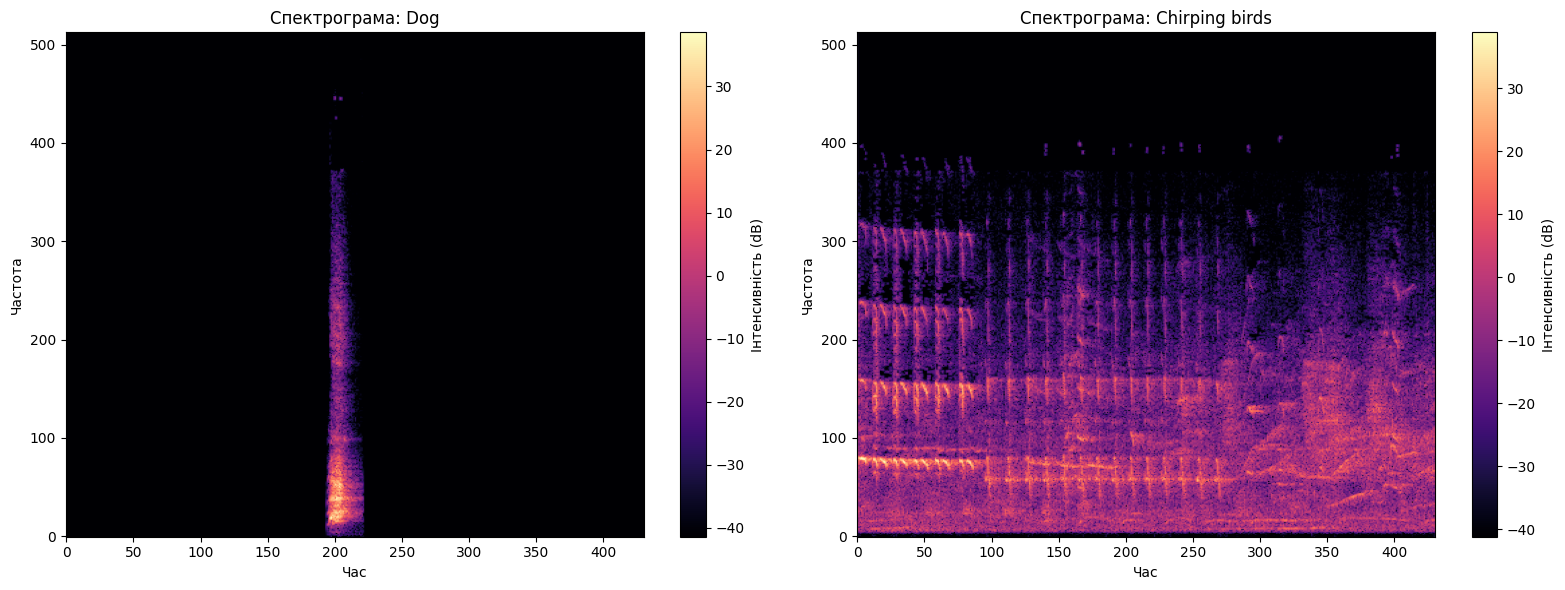

In [ ]:
# Собаки
subset_dogs = meta[meta['category'] == 'dog']
filename_dog = subset_dogs.loc[subset_dogs.index[0], 'filename']
file_path_dog = f"{audio_dir}/{filename_dog}"

# Птахи
subset_birds = meta[meta['category'] == 'chirping_birds']
filename_birds = subset_birds.loc[subset_birds.index[0], 'filename']
file_path_birds = f"{audio_dir}/{filename_birds}"

# Спектрограми
S_db_dog = spectrogram(file_path_dog)
S_db_birds = spectrogram(file_path_birds)

# Візуалізація поруч
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

img1 = axes[0].imshow(S_db_dog, aspect='auto', origin='lower', cmap='magma')
axes[0].set_title('Спектрограма: Dog')
axes[0].set_xlabel('Час')
axes[0].set_ylabel('Частота')
fig.colorbar(img1, ax=axes[0], label='Інтенсивність (dB)')

img2 = axes[1].imshow(S_db_birds, aspect='auto', origin='lower', cmap='magma')
axes[1].set_title('Спектрограма: Chirping birds')
axes[1].set_xlabel('Час')
axes[1].set_ylabel('Частота')
fig.colorbar(img2, ax=axes[1], label='Інтенсивність (dB)')

plt.tight_layout()
plt.show()

In [38]:

X, y_true = build_feature_matrix(subset, pool_size=(5, 5))
X_scaled = StandardScaler().fit_transform(X)
clusters = SpectralClustering(n_clusters=2, affinity='nearest_neighbors', random_state=42).fit_predict(X_scaled)
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)


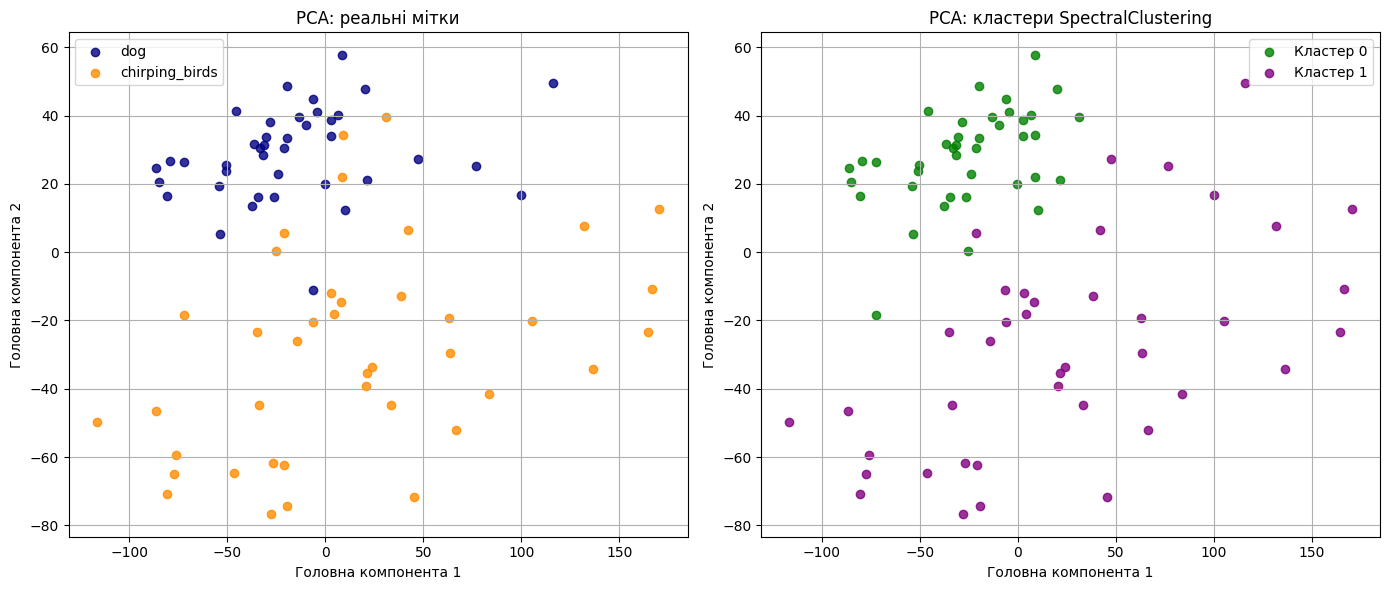

In [39]:
# Використовуємо вже готові X_pca, y_true, clusters з попередніх кроків
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Графік 1: реальні мітки (dog / chirping_birds)
for color, label in zip(['navy', 'darkorange'], ['dog', 'chirping_birds']):
    mask = y_true == label
    axes[0].scatter(X_pca[mask, 0], X_pca[mask, 1], color=color, alpha=0.8, label=label)
axes[0].set_title('PCA: реальні мітки')
axes[0].set_xlabel('Головна компонента 1')
axes[0].set_ylabel('Головна компонента 2')
axes[0].legend()
axes[0].grid(True)

# Графік 2: кластери, знайдені SpectralClustering
for color, cluster_id in zip(['green', 'purple'], [0, 1]):
    mask = clusters == cluster_id
    axes[1].scatter(X_pca[mask, 0], X_pca[mask, 1], color=color, alpha=0.8, label=f'Кластер {cluster_id}')
axes[1].set_title('PCA: кластери SpectralClustering')
axes[1].set_xlabel('Головна компонента 1')
axes[1].set_ylabel('Головна компонента 2')
axes[1].legend()
axes[1].grid(True)

plt.tight_layout()
plt.show()



Висновок

Перетворення Фур'є (STFT) дало змогу побудувати спектрограми звуків `dog` та `chirping_birds` і використати їх для кластеризації методом `SpectralClustering`.

Найкращий результат — ARI = 0.557 (pooling 5×5). Це помітно краще за випадковий поділ (ARI=0), хоча й не ідеальний збіг (ARI=1).

Розмір pooling сильно впливає на якість кластеризації:
Малий pooling (2×2)** дає забагато ознак (55040) відносно кількості файлів (80) — відстані між точками стають майже однаковими, і алгоритм гірше розрізняє класи (ARI=0.383).
Великий pooling (10×10–20×20)** надто сильно усереднює спектрограму — зникають короткі гострі частотні патерни, що відрізняють гавкіт від щебету (ARI падає до 0.151–0.267).
Оптимум — 5×5: достатньо деталей, і розмірність ще не заважає алгоритму.

`StandardScaler` перед кластеризацією потрібен був, щоб вирівняти масштаб значень спектрограми (дБ можуть відрізнятись через гучність запису) — інакше окремі ознаки домінували б при рахунку відстаней.

PCA-візуалізація підтвердила результат: реальні мітки й знайдені кластери розподіляються схожим чином на графіку.

Загальний висновок: FFT перетворює звук з часової форми (амплітуда в часі) на частотний спектр — саме частотний склад дозволяє порівнювати звуки й кластеризувати їх. Без FFT працювати напряму з сирим сигналом було б значно складніше.